# Goal:

Now that we have tested the log-likelihood cost function and the target optimization for 1Q with reasonable success, we move onto 2Q to verify if the optimization hyper parameters hold equally well.

In [40]:
import jax.numpy as jnp

from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration
from mGST.gauge_analysis import max_num_parameters, min_num_parameters
from mGST.utility_functions_comparisons import all_operators_from_configuration, kraus_tensor_to_mgst, get_compressed_rep_from_mgst_output, get_compressed_perturbed_kraus_from_superop, get_compressed_perturbed_rep_from_mgst
from mGST.typing import OperatorSchedule, TrustRegionOptions
from mGST.simulate import run_optimization_workflow
from mGST.visualization import plot_cost_function

backend = "iqmfakeapollo" # just to create the benchmark and then get the gate set

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Initial and target tensors

In [11]:
# define the parameters for the Gate set to determine the number of sequences.
num_qubits = 2
dim = 2**num_qubits
kraus_rank = dim
povm_rank = dim
state_rank = dim
num_gates = 6
num_shots = 1000

In [12]:
# what are the max and min number of parameters for this configuration?
upper_bound = max_num_parameters(num_qubits=num_qubits, num_gates=num_gates, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)
lower_bound = min_num_parameters(num_qubits=num_qubits, num_gates=num_gates, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

print(f"Upper bound: {upper_bound}, Lower bound: {lower_bound}")

Upper bound: 815, Lower bound: 623


In [ ]:
num_sequences = 1000 # based on the max and min

In [14]:
configuration = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYICZ",
    num_circuits=num_sequences,
    shots=num_shots,
    rank=kraus_rank,
    verbose_level=2,
    from_init = True,
    )

target_operators = all_operators_from_configuration(configuration, backend)
print(target_operators.keys())

# now get the superoperator for Kraus
povm_vect_target = target_operators["povm"]
state_vect_target = target_operators["state"]
kraus_tensor_unitary_target = target_operators["kraus"]
kraus_superop_target = kraus_tensor_to_mgst(kraus_tensor_unitary_target)

INFO:2026-07-19 14:57:45,028:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-07-19 14:57:45,028 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-07-19 14:57:45,032:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/

dict_keys(['kraus', 'povm', 'state', 'gate_labels'])


In [18]:
kraus_tensor_target, povm_psd_target, state_psd_target = get_compressed_rep_from_mgst_output(kraus_superop_target, povm_vect_target, state_vect_target, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

target_psd_operators = {
    "kraus": kraus_tensor_target,
    "povm": povm_psd_target,
    "state": state_psd_target
}
print("Target operators PSD:", [op.shape for op in target_psd_operators.values()])

kraus_tensor_init_dict = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=kraus_rank, seed=42)
kraus_tensor_init = kraus_tensor_init_dict["kraus_tensor"]

povm_psd_init, state_psd_init = get_compressed_perturbed_rep_from_mgst(povm_vect_target, state_vect_target, rank_povm=povm_rank, rank_state=state_rank)

init_operators = {
    "kraus": kraus_tensor_init,
    "povm": povm_psd_init,
    "state": state_psd_init,
}

true_superops={
    "kraus": kraus_superop_target,
    "povm": povm_vect_target,
    "state": state_vect_target
}

print(f"Init operators PSD: {[v.shape for v in init_operators.values()]}")
print(f"Target superops: {[v.shape for v in true_superops.values()]}")

Target operators PSD: [(6, 4, 4, 4), (4, 4, 4), (4, 4)]
Init operators PSD: [(6, 4, 4, 4), (4, 4, 4), (4, 4)]
Target superops: [(6, 16, 16), (4, 16), (16,)]


# Optimization

In [20]:
num_iterations_outer = 20
num_iterations_tr = 5
num_iterations_cg = 10 
tol_grad = 1e-8 # it was 1e-4 before. 1e-8 is suggested in the book.

tr_schedule_verbose = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=False, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad))

relative_precision = 1e-11 # decreased a bit compared to 1Q
global_grad_norm_tol = 1e-8 # decreased a bit compared to 1Q

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}

optimization_options = {
    "schedule": optimization_schedule_all_tr,
    "num_iterations_outer": num_iterations_outer,
    "relative_precision": relative_precision,
    "global_gradient_norm_tol": global_grad_norm_tol
}
optimization_options

{'schedule': {'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))])},
 'num_iterations_outer': 20,
 'relative_precision': 1e-11,
 'global_gradient_norm_tol': 1e-08}

In [22]:
optimization_results_exact_least_squares = run_optimization_workflow(
    num_sequences=num_sequences,
    num_shots=1, # since we are using the exact probabilities.
    init_operators=init_operators,
    operators_psd_true=target_psd_operators,
    target_superops=true_superops,
    use_exact_probabilities=True,
    optimization_options=optimization_options,
    warmup_run=True,
    optimization_verbose=True,
    use_log_likelihood=False,
)

Using exact probabilities 🔪
🏎️ Warming up the cost function ...
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:364: UserWarning: Setting num_shots=1 when using exact probs.
  warnings.warn("Setting num_shots=1 when using exact probs.")


at iteration 43 the new count changed to: 4
at iteration 119 the new count changed to: 5
at iteration 195 the new count changed to: 6
at iteration 271 the new count changed to: 7
at iteration 347 the new count changed to: 8
at iteration 423 the new count changed to: 9
at iteration 500 the new count changed to: 10
at iteration 583 the new count changed to: 11
at iteration 666 the new count changed to: 12
at iteration 749 the new count changed to: 13
at iteration 832 the new count changed to: 14
at iteration 916 the new count changed to: 15
Initial cost value: 0.0010474449731337021
🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-19]: TrustRegionOptions
povm: Schedule:
  [0-19]: TrustRegionOptions
state: Schedule:
  [0-19]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-11 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.047445e-03. |r∇f(x)|: 5.056898e-03. Radius: 1.00e-01
TR Iteration: 1

In [29]:
optimization_results_exact_loglikelihood = run_optimization_workflow(
    num_sequences=num_sequences,
    num_shots=1, # since we are using the exact probabilities.
    init_operators=init_operators,
    operators_psd_true=target_psd_operators,
    target_superops=true_superops,
    use_exact_probabilities=True,
    optimization_options=optimization_options,
    warmup_run=True,
    optimization_verbose=True,
    use_log_likelihood=True,
    compute_least_squares=True,
)

Using exact probabilities 🔪
Using log-likelihood for the cost function optimization 🧮
🏎️ Warming up the cost function ...
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:364: UserWarning: Setting num_shots=1 when using exact probs.
  warnings.warn("Setting num_shots=1 when using exact probs.")


at iteration 43 the new count changed to: 4
at iteration 119 the new count changed to: 5
at iteration 195 the new count changed to: 6
at iteration 271 the new count changed to: 7
at iteration 347 the new count changed to: 8
at iteration 423 the new count changed to: 9
at iteration 500 the new count changed to: 10
at iteration 583 the new count changed to: 11
at iteration 666 the new count changed to: 12
at iteration 749 the new count changed to: 13
at iteration 832 the new count changed to: 14
at iteration 916 the new count changed to: 15
Initial cost value: 943.3687528072784
🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-19]: TrustRegionOptions
povm: Schedule:
  [0-19]: TrustRegionOptions
state: Schedule:
  [0-19]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-11 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 9.433688e+02. |r∇f(x)|: 4.907216e+01. Radius: 1.00e-01
TR Iteration: 1. f(

In [30]:
cost_fn_loglikelihood_exact = optimization_results_exact_loglikelihood["cost_fn_history"]
type(cost_fn_loglikelihood_exact)

list

In [35]:
from mGST.low_level_jit import cost_function_jax_mps

In [36]:
optimized_operators_loglikelihood = optimization_results_exact_loglikelihood["optimized_operators"]
prob_matrix_exact = optimization_results_exact_loglikelihood["probability_matrices"]["exact"]
indices_list = optimization_results_exact_loglikelihood["indices_dict"]["gate_indices"]

cost_fn_kwargs = {
    "prob_matrix": prob_matrix_exact,
    "indices_list": indices_list,
    "jit": True,
}

cost_least_squares_from_loglikelihood = cost_function_jax_mps(*optimized_operators_loglikelihood.values(), **cost_fn_kwargs)
cost_least_squares_from_loglikelihood

Array(2.29689509e-13, dtype=float64)

In [49]:
tr_schedule_verbose

OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))])

In [50]:
optimization_options_easy = {
    "schedule": optimization_schedule_all_tr,
    "num_iterations_outer": num_iterations_outer,
    "relative_precision": 1e-9,
    "global_gradient_norm_tol": global_grad_norm_tol,
}
optimization_options_easy

{'schedule': {'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))])},
 'num_iterations_outer': 20,
 'relative_precision': 1e-09,
 'global_gradient_norm_tol': 1e-08}

In [51]:
optimization_results_exact_loglikelihood_test = run_optimization_workflow(
    num_sequences=num_sequences,
    num_shots=1, # since we are using the exact probabilities.
    init_operators=init_operators,
    operators_psd_true=target_psd_operators,
    target_superops=true_superops,
    use_exact_probabilities=True,
    optimization_options=optimization_options_easy,
    warmup_run=False,
    optimization_verbose=True,
    use_log_likelihood=True,
    compute_least_squares=True,
)

Using exact probabilities 🔪
Using log-likelihood for the cost function optimization 🧮
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-19]: TrustRegionOptions
povm: Schedule:
  [0-19]: TrustRegionOptions
state: Schedule:
  [0-19]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-09 
+ Gradient(s) Norm(s) 📐


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/simulate.py:363: UserWarning: Setting num_shots=1 when using exact probs.
  print("Using exact probabilities 🔪")


🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 9.321881e+02. |r∇f(x)|: 5.263243e+01. Radius: 1.00e-01
TR Iteration: 1. f(x): 9.292964e+02. |r∇f(x)|: 7.874066e+00. Radius: 2.00e-01
TR Iteration: 2. f(x): 9.292223e+02. |r∇f(x)|: 4.818714e-01. Radius: 2.00e-01
TR Iteration: 3. f(x): 9.292221e+02. |r∇f(x)|: 4.601061e-03. Radius: 2.00e-01
TR Iteration: 4. f(x): 9.292221e+02. |r∇f(x)|: 2.762375e-06. Radius: 2.00e-01
Update rejected ❌.
Optimization finished ✅. 
 Iters: 5. f(x): 9.292221e+02. |r∇f(x)|: 2.762375e-06. Radius: 5.00e-02. Rejections: 1

 🎯 [Povm] Relative change in cost function value: 3.18e-03. Target: 1.00e-09.
🚀 TR started for operator: kraus 🚀.
TR Iteration: 0. f(x): 9.292221e+02. |r∇f(x)|: 1.773383e+02. Radius: 1.00e-01
TR Iteration: 1. f(x): 9.201974e+02. |r∇f(x)|: 5.778931e+01. Radius: 2.00e-01
TR Iteration: 2. f(x): 9.154828e+02. |r∇f(x)|: 1.299328e+01. Radius: 4.00e-01
TR Iteration: 3. f(x): 9.151495e+02. |r∇f(x)|: 1.703128e+00. Radius: 4.00e-01
TR Iteration: 4.

In [52]:
optimization_results_exact_loglikelihood_test["cost_fn_history"].keys()

dict_keys(['cost_fn_history', 'cost_fn_least_squares'])

# Visualization

In [27]:
optimization_results_exact_least_squares["times"]

{'optimization_time': 4219.757062911987,
 'gauge_time': 1.8064420223236084,
 'compilation_time': 1.1594059467315674}

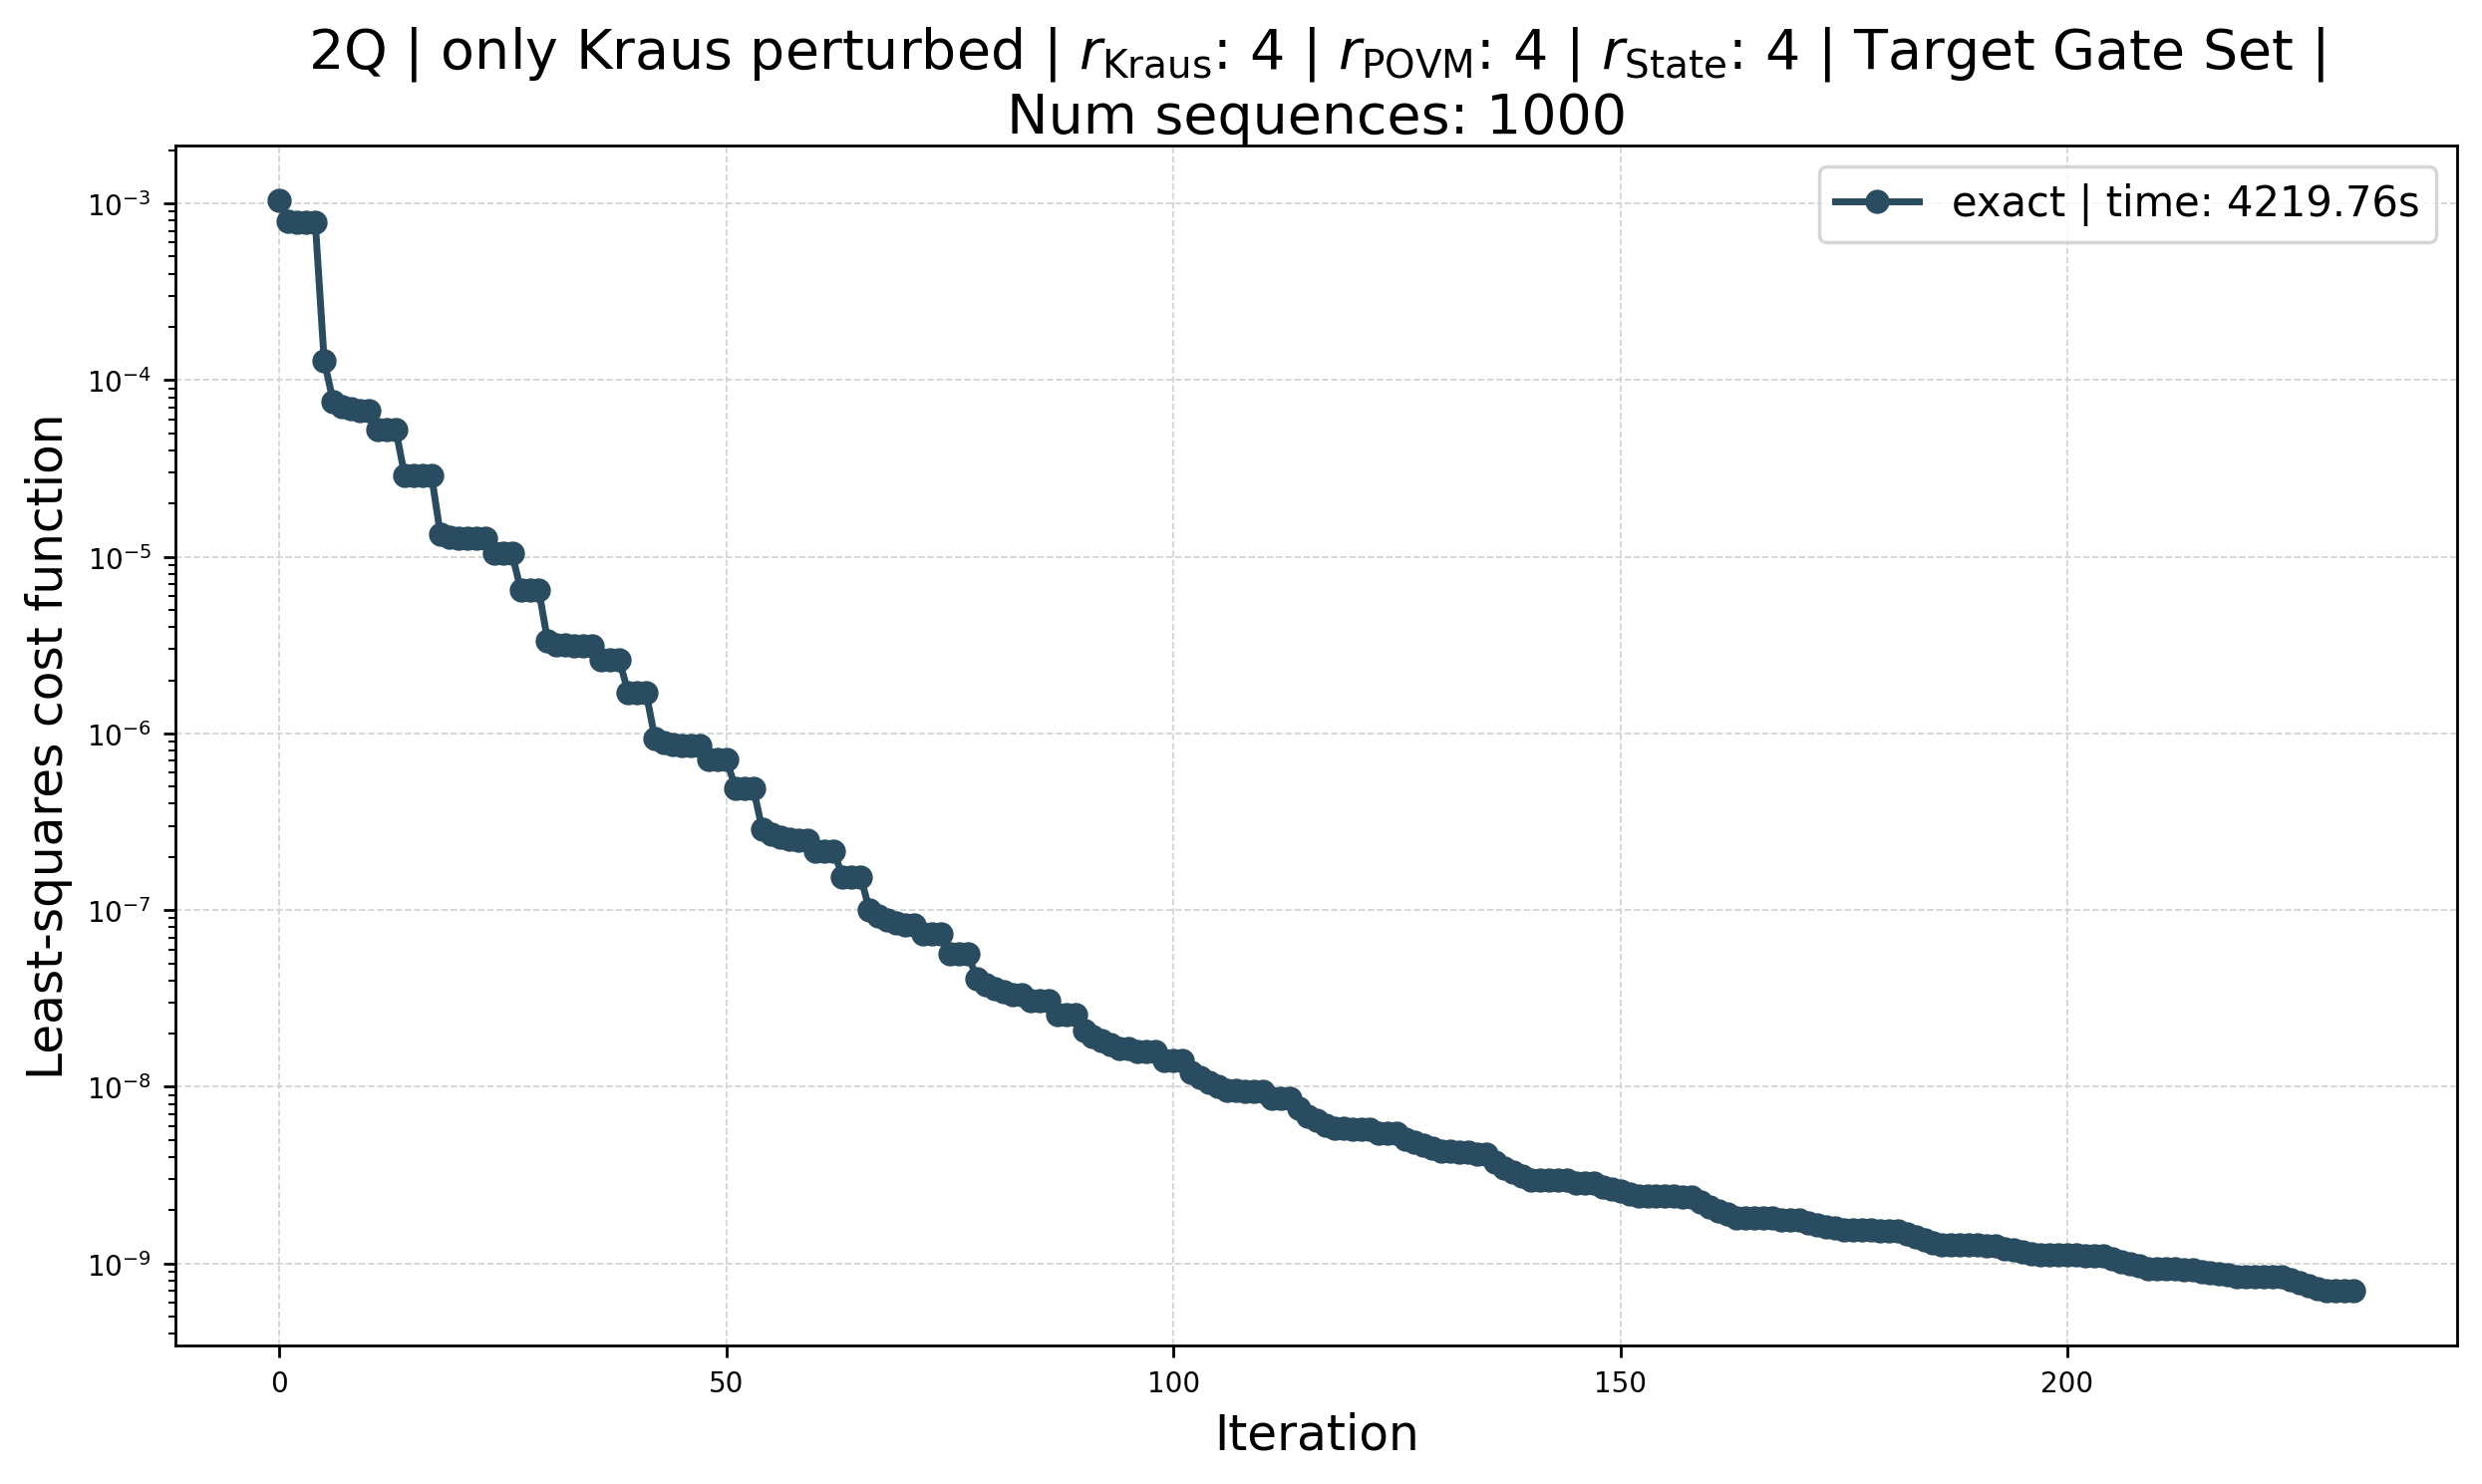

In [33]:
cost_fn_list = [optimization_results_exact_least_squares["cost_fn_history"]]

times = [optimization_results_exact_least_squares["times"]["optimization_time"]]

title_cost_fn_vs_shots = rf"{num_qubits}Q | only Kraus perturbed | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Target Gate Set |" + "\n" + f"Num sequences: {num_sequences}"

labels = [f"exact | time: {times[0]:.2f}s"]

ylabel_cost_fn = "Least-squares cost function"

plot_cost_function(cost_fn_list, title=title_cost_fn_vs_shots, labels=labels[:1], comparison_yline=None, ylabel=ylabel_cost_fn)

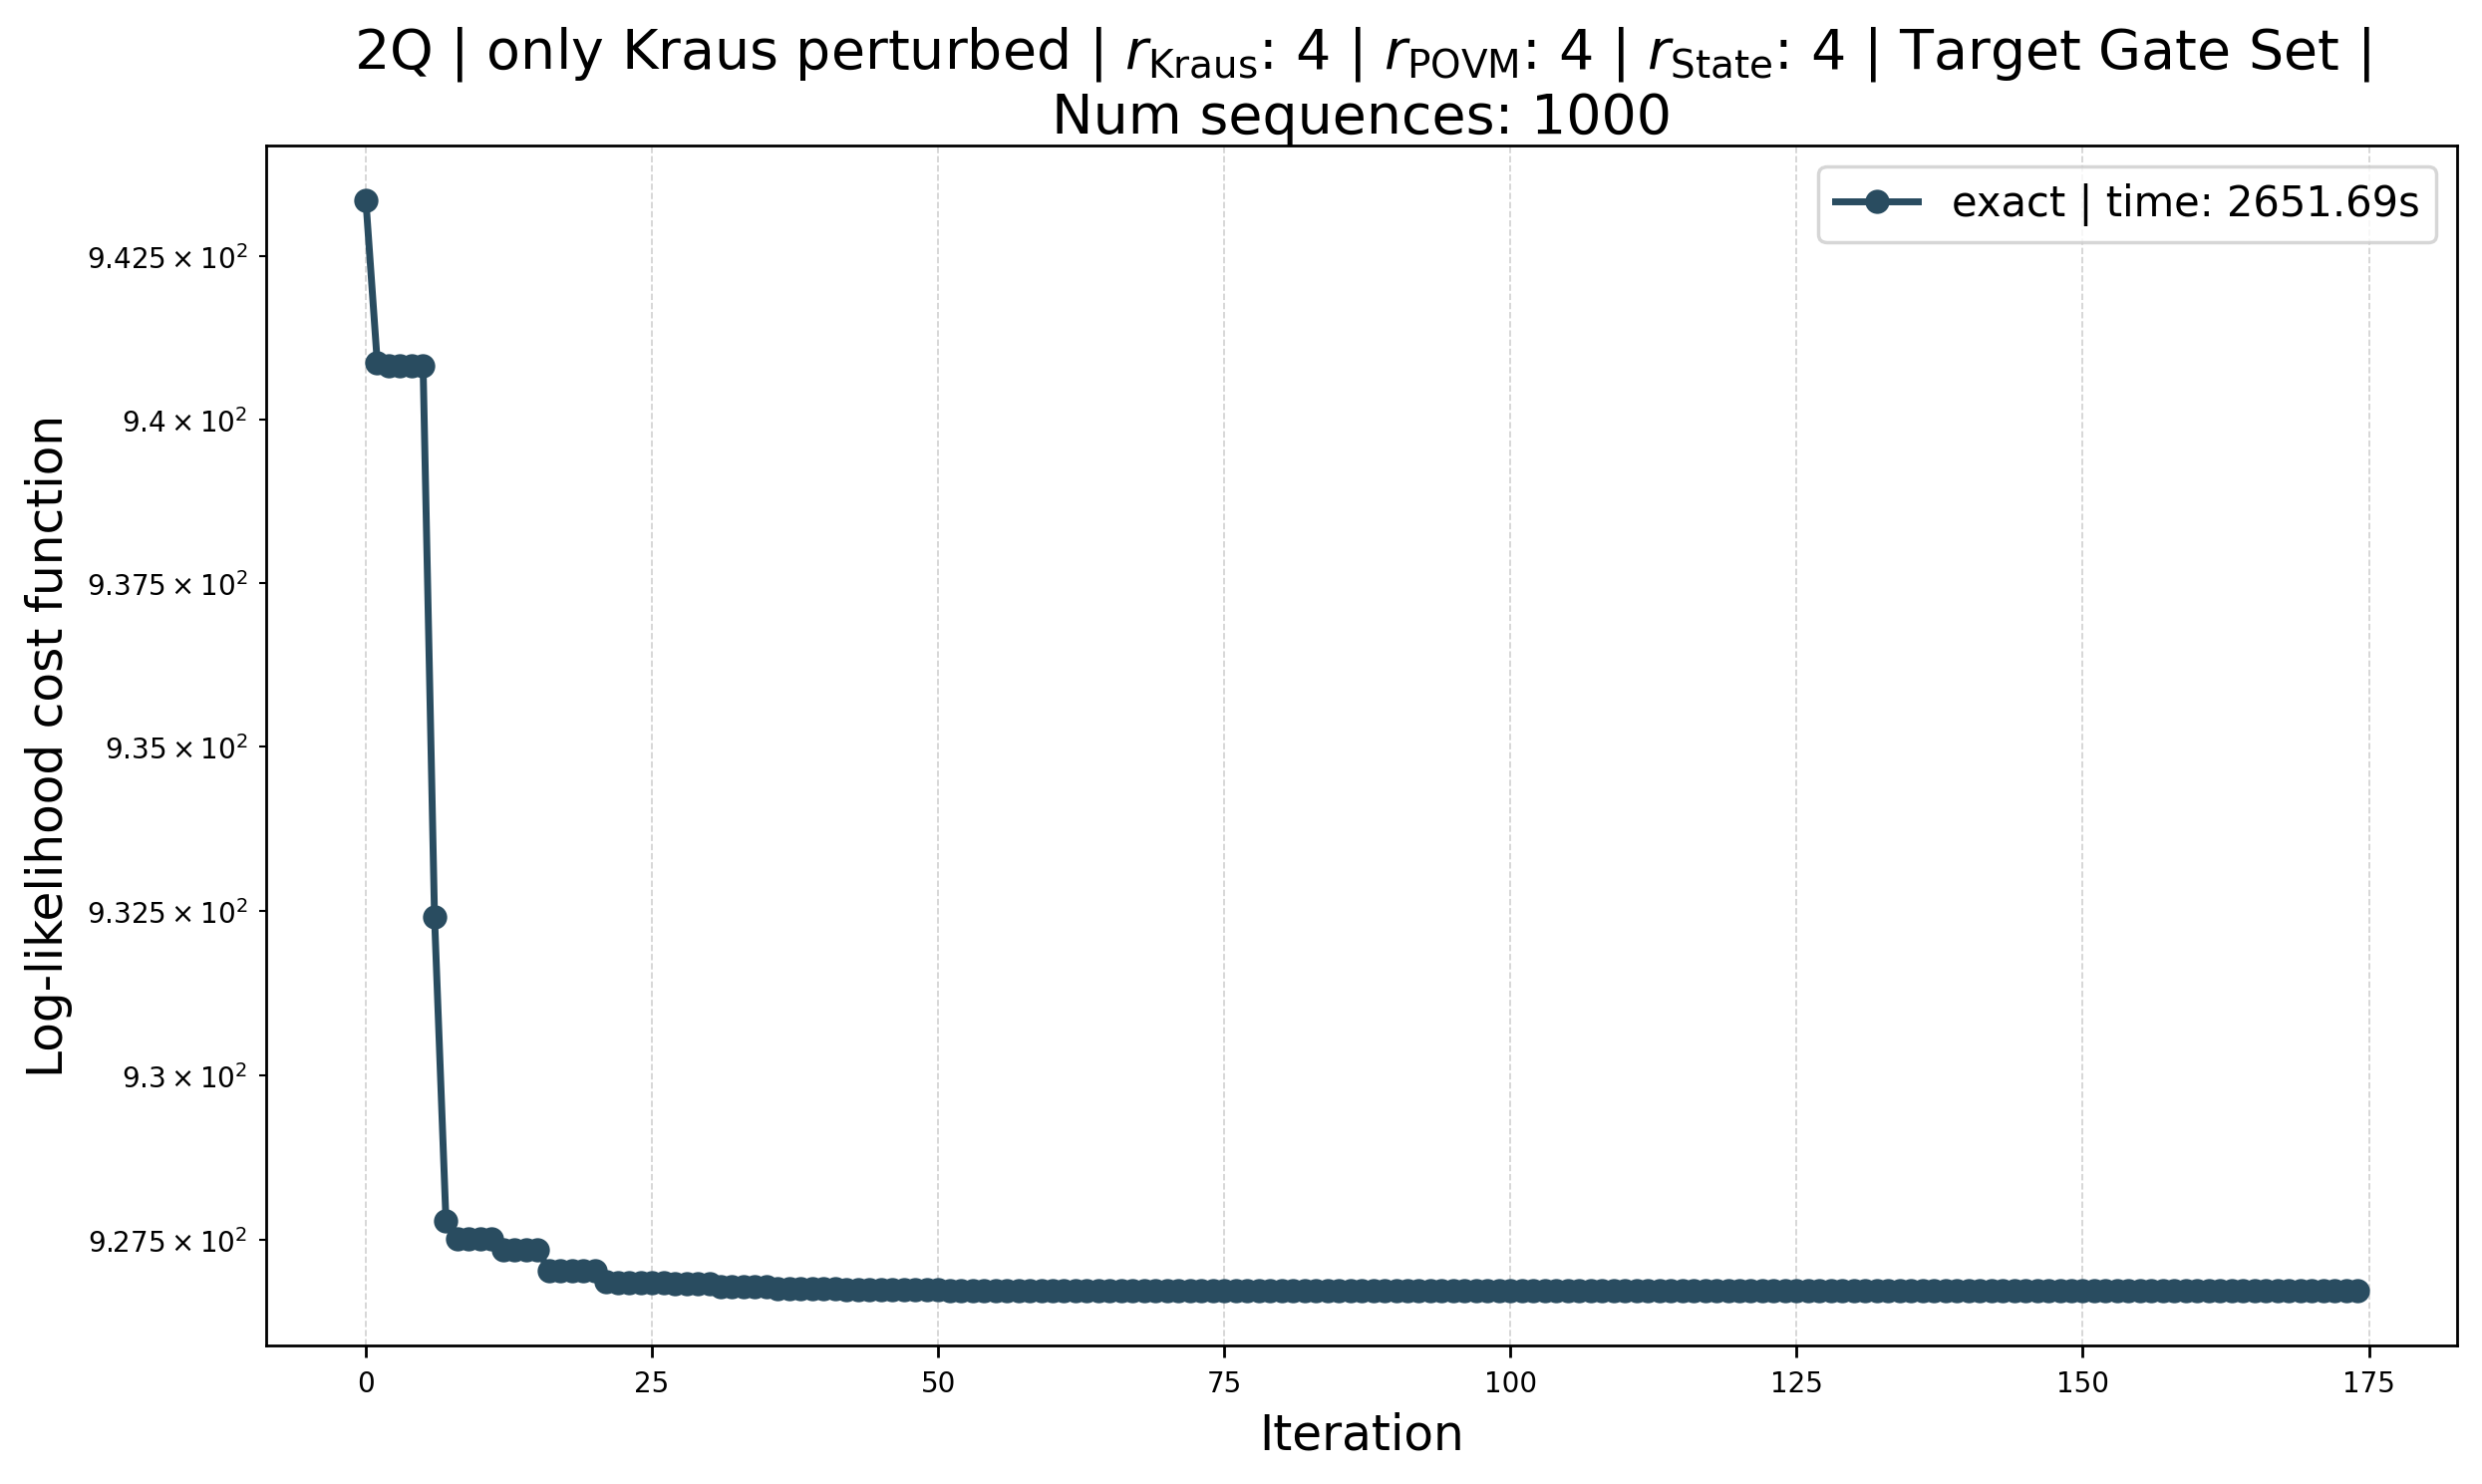

In [ ]:
times_loglikelihood = [optimization_results_exact_loglikelihood["times"]["optimization_time"]]
labels_loglikelihood = [f"exact | time: {times_loglikelihood[0]:.2f}s"]

ylabel_cost_fn = "Log-likelihood cost function"

plot_cost_function([cost_fn_loglikelihood_exact], title=title_cost_fn_vs_shots, labels=labels_loglikelihood, comparison_yline=None, ylabel=ylabel_cost_fn)

In [59]:
def compute_least_squares_from_optimization_result(optimization_result, probability_type:str="sampled"):
    "Utility function to compute the least squares value from the optimization result."
    optimized_ops = optimization_result["optimized_operators"]
    indices_list = optimization_result["indices_dict"]["gate_indices"]
    prob_matrix = optimization_result["probability_matrices"][probability_type]
    return cost_function_jax_mps(*optimized_ops.values(), indices_list=indices_list, prob_matrix=prob_matrix, jit=True, use_log_likelihood=False)

In [ ]:
least_squares_test = compute_least_squares_from_optimization_result(optimization_results_exact_loglikelihood_test, probability_type="exact")
least_squares_test

Array(2.28677094e-11, dtype=float64)

In [77]:
optimization_results_exact_loglikelihood_test["cost_fn_history"]["cost_fn_least_squares"]

[Array(6.33353491e-05, dtype=float64),
 Array(1.08090282e-05, dtype=float64),
 Array(2.29435793e-06, dtype=float64),
 Array(5.12303971e-07, dtype=float64),
 Array(1.16527465e-07, dtype=float64),
 Array(2.67660798e-08, dtype=float64),
 Array(6.18538907e-09, dtype=float64),
 Array(1.43493259e-09, dtype=float64),
 Array(3.33739141e-10, dtype=float64),
 Array(7.77628694e-11, dtype=float64)]

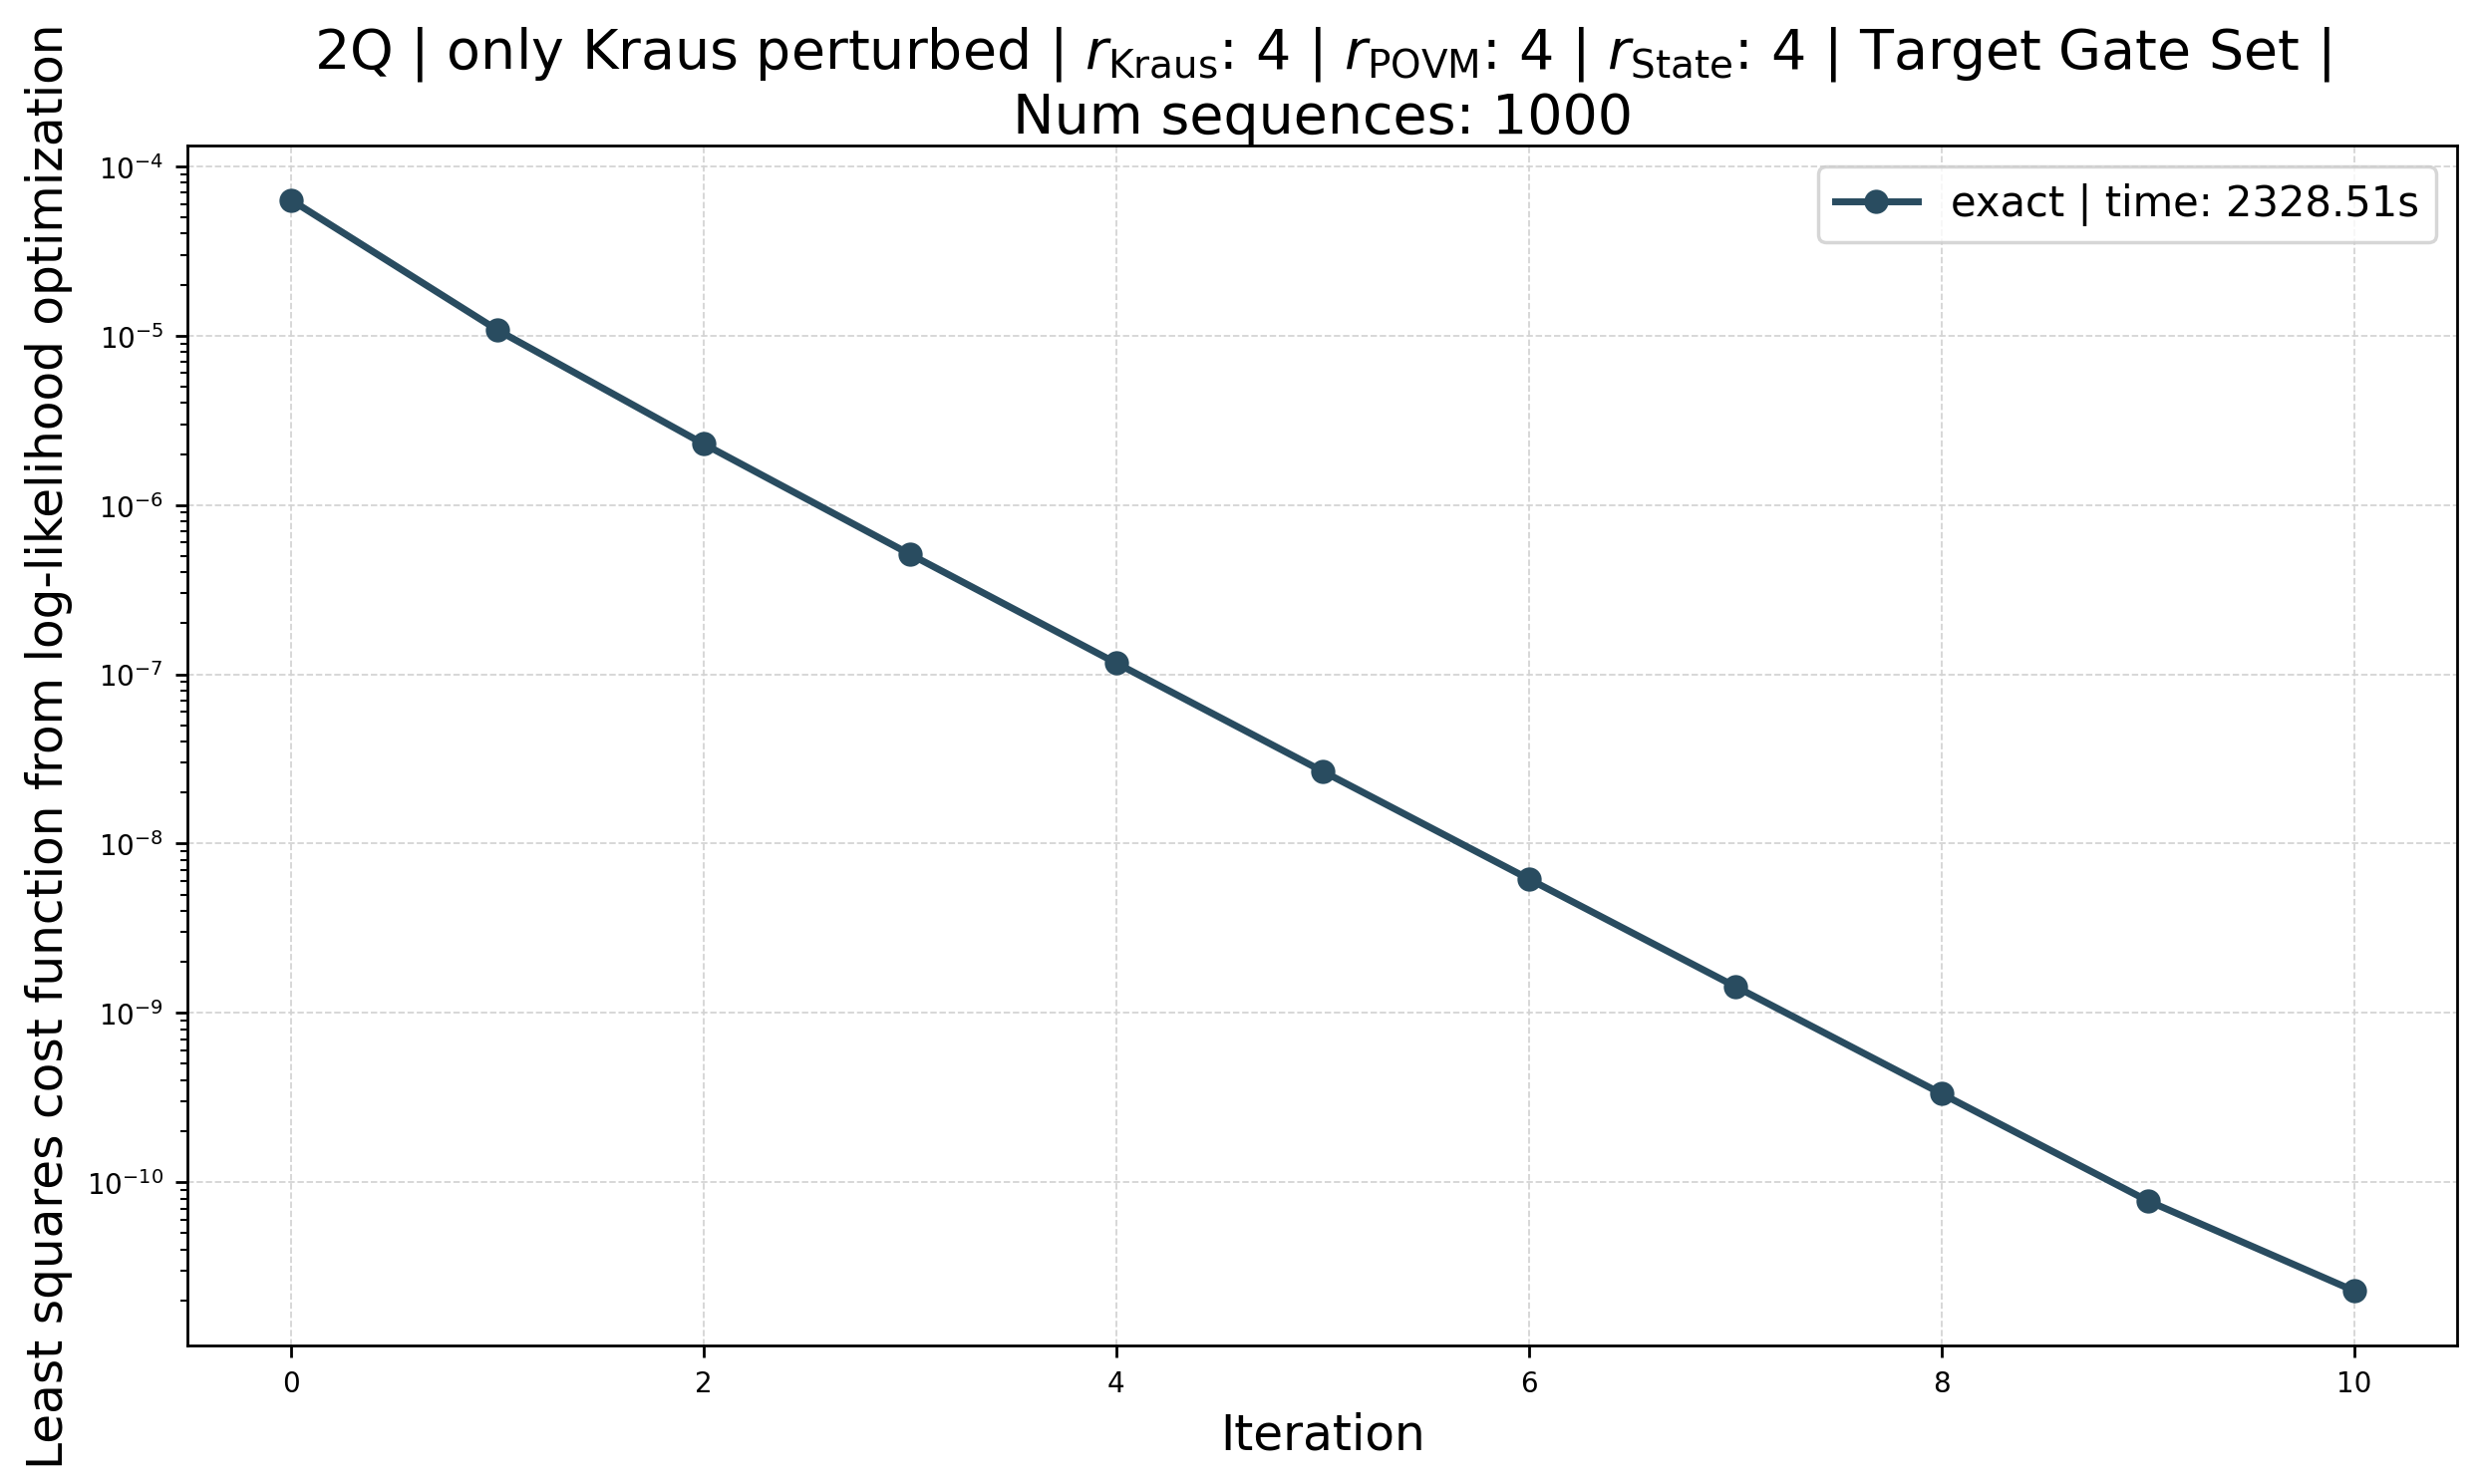

In [79]:
labels_loglikelihood = [f"exact | time: {optimization_results_exact_loglikelihood_test['times']['optimization_time']:.2f}s"]

ylabel_cost_fn = "Least squares cost function from log-likelihood optimization"

cost_fn_least_squares_test = optimization_results_exact_loglikelihood_test["cost_fn_history"]["cost_fn_least_squares"].copy()

cost_fn_least_squares_test.append(least_squares_test)

cost_fn_least_squares_list = [cost_fn_least_squares_test]


plot_cost_function(cost_fn_least_squares_list, title=title_cost_fn_vs_shots, labels=labels_loglikelihood, comparison_yline=None, ylabel=ylabel_cost_fn)

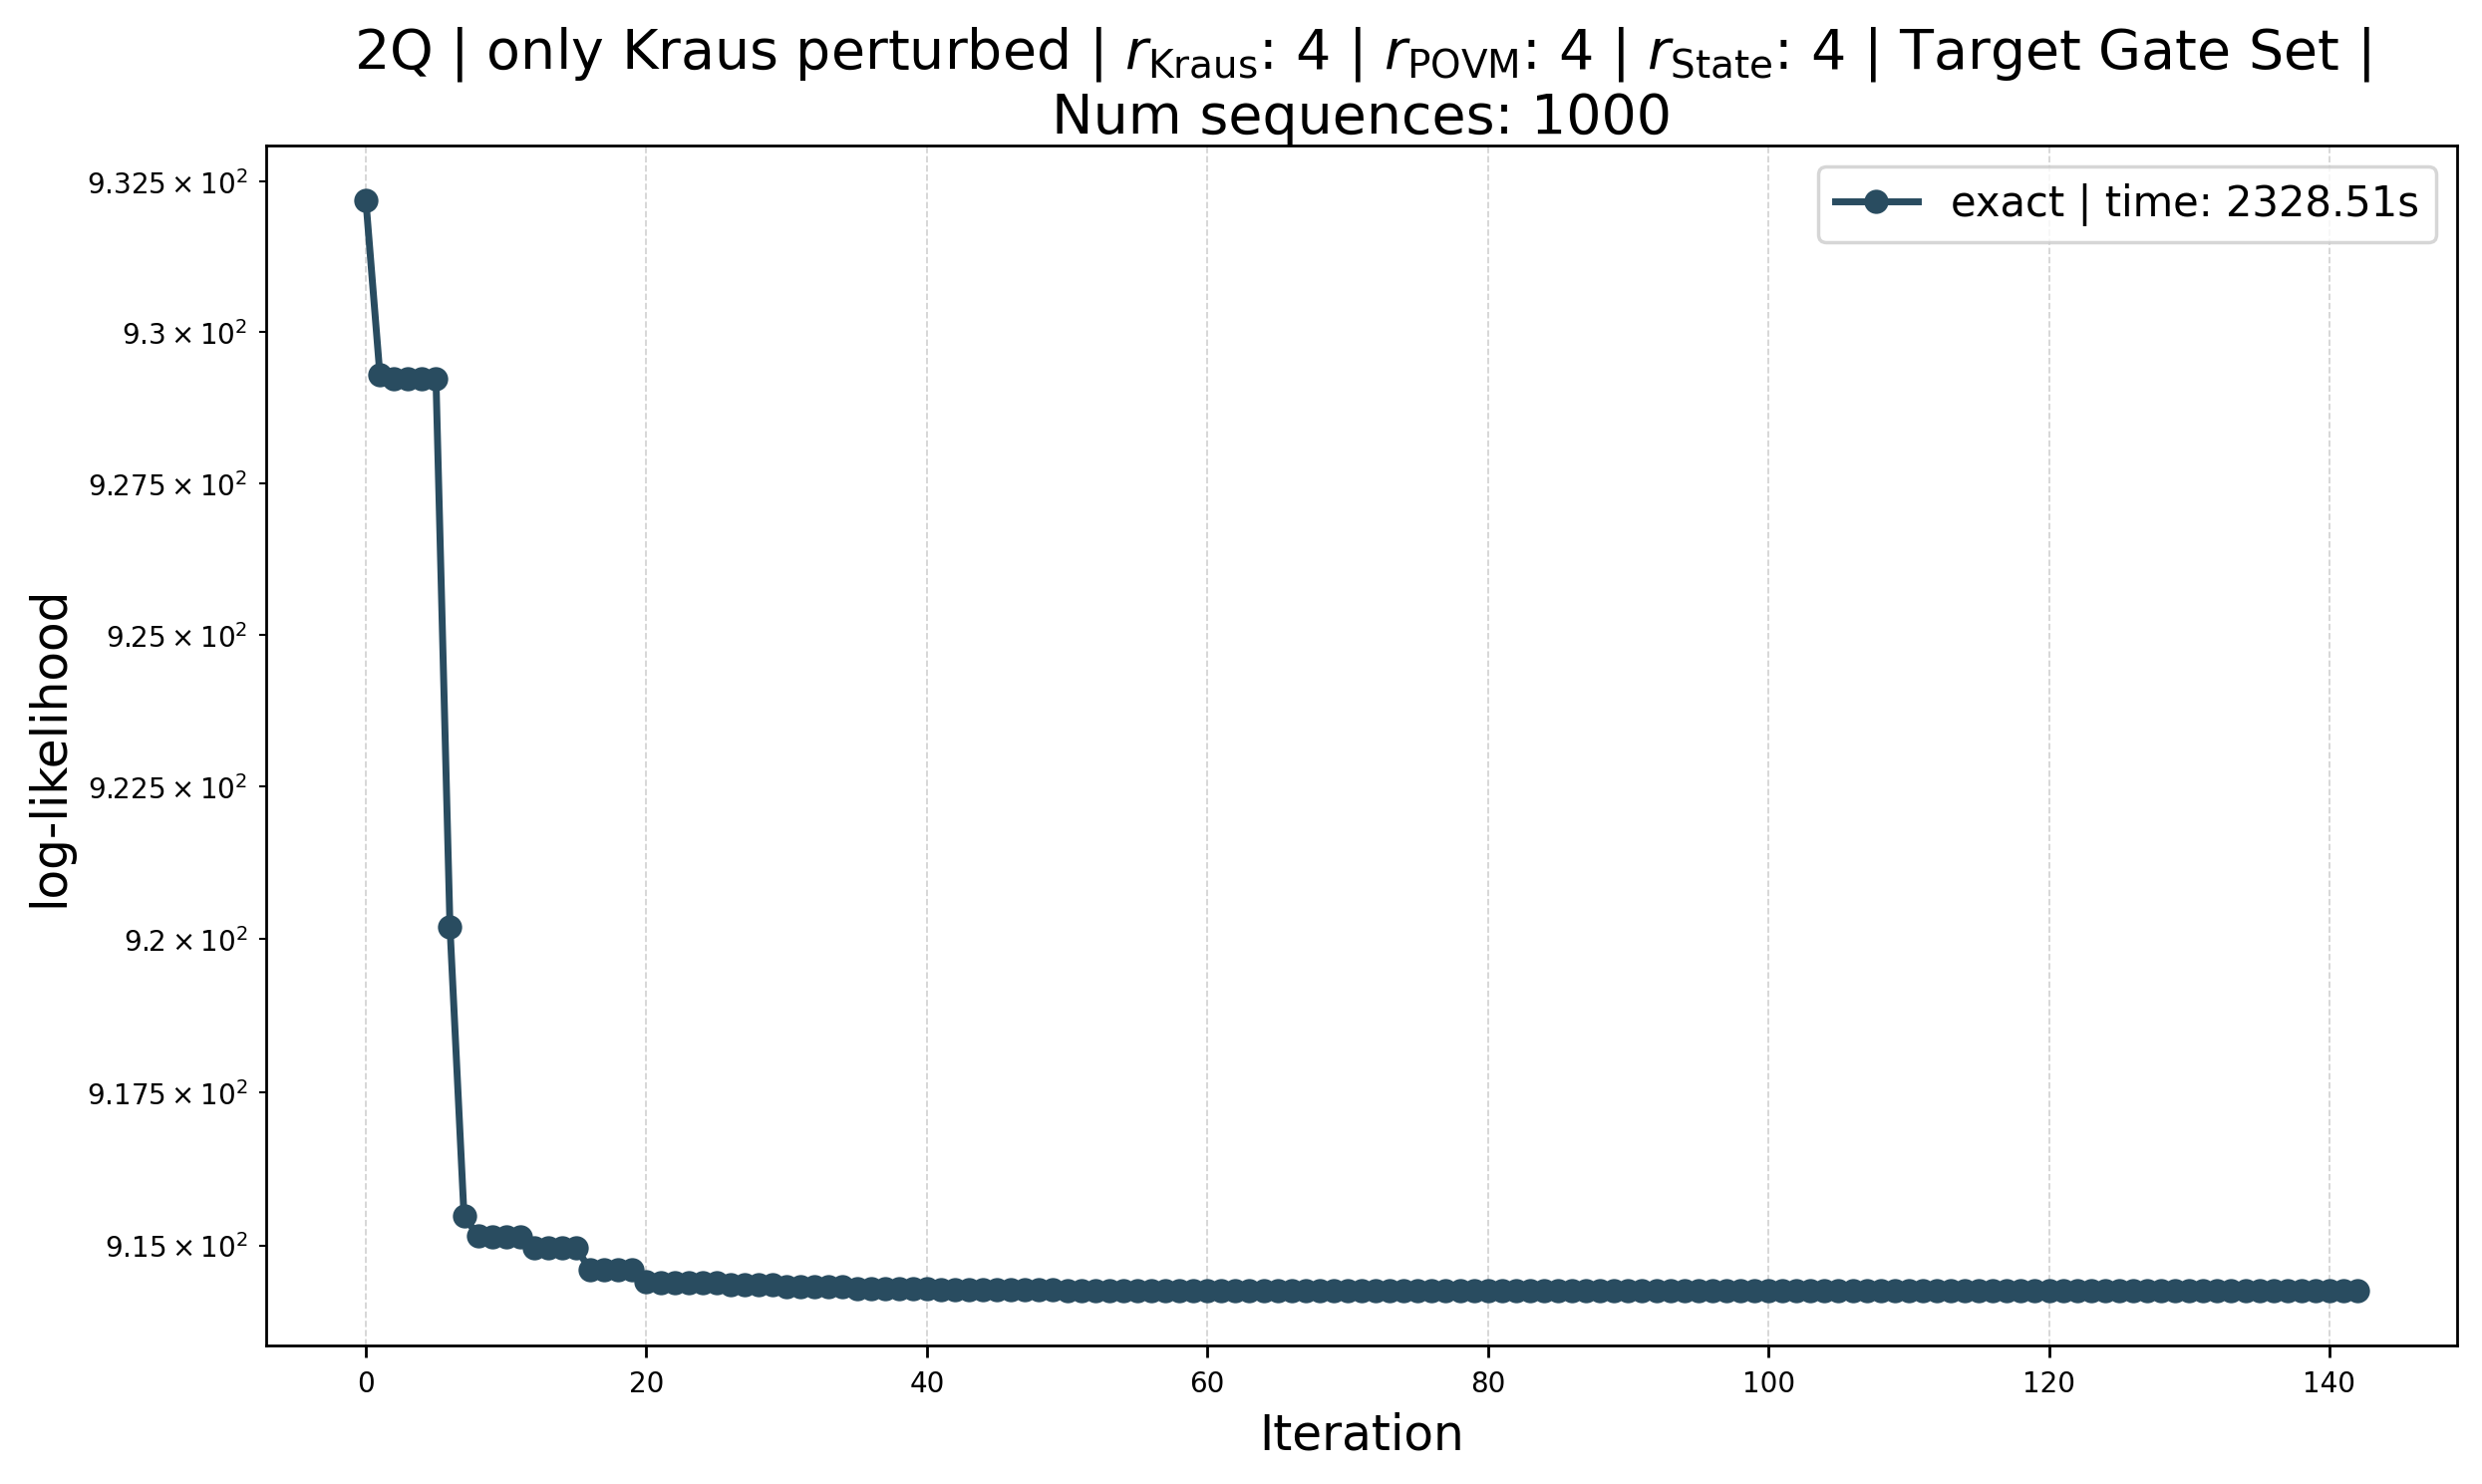

In [55]:
plot_cost_function([optimization_results_exact_loglikelihood_test["cost_fn_history"]["cost_fn_history"]], title=title_cost_fn_vs_shots, labels=labels_loglikelihood, comparison_yline=None, ylabel="log-likelihood")